# Autonomous Ocean Robotics: 4D Profiling with Argo Floats

**Objective:** Query the global, live database of autonomous Argo profiling floats to extract and visualise 4D oceanographic profiles (temperature and salinity vs. depth).
*   **The Problem:** Traditional ocean sampling requires expensive research vessels. To monitor vast, remote areas (such as the Western Australian coast), we need to collect data from autonomous robotic fleets that dive to 2,000 metres and transmit it back via satellite.
*   **The Solution:** This pipeline uses the `argopy` library to dynamically query the live Argo database via the API, filtering by specific geographic bounding boxes and timeframes. We then convert the 4D data cube into vertical profile visualisations.
*   **Key Libraries:** `argopy`, `xarray`, `pandas`, `matplotlib`

In [1]:
from argopy import DataFetcher
import matplotlib.pyplot as plt

print("Initializing connection to the Argo global database...")

# Define the bounding box off the coast of Western Australia
# Format: [lon_min, lon_max, lat_min, lat_max, depth_min, depth_max, time_start, time_end]
wa_region = [110, 115, -35, -25, 0, 1500, '2025-12-01', '2026-01-01']

# Fetch the data and convert it directly to an xarray dataset
fetcher = DataFetcher(mode='standard').region(wa_region)
argo_data = fetcher.to_xarray()

print(f"Success! Downloaded {len(argo_data.TIME)} oceanographic measurement points.")

Initializing connection to the Argo global database...
Success! Downloaded 11255 oceanographic measurement points.


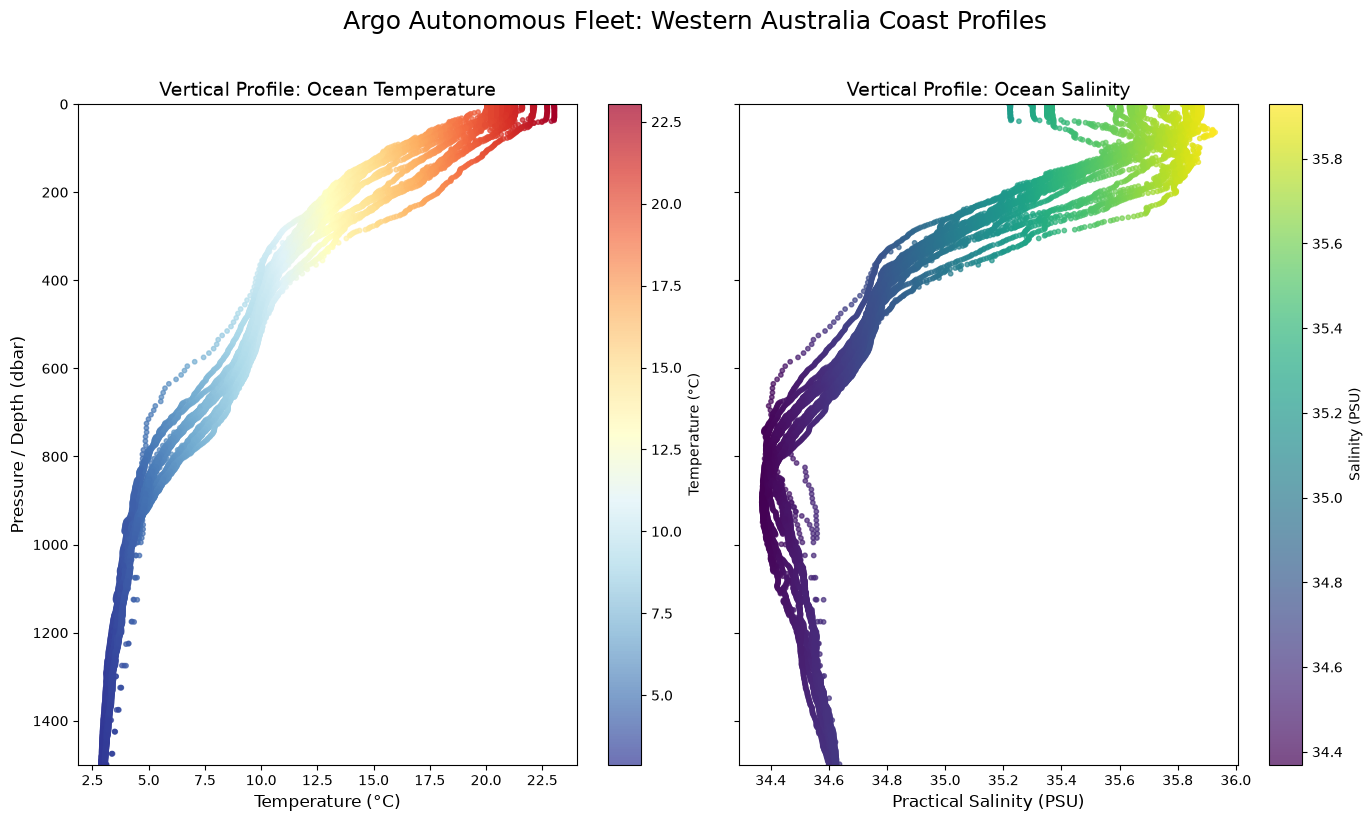

In [2]:
# Convert the xarray dataset to a Pandas DataFrame for easier scatter plotting
df = argo_data.to_dataframe().reset_index()

# Set up the visualization canvas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8), sharey=True)

# Plot 1: Temperature vs Depth
scatter1 = ax1.scatter(df['TEMP'], df['PRES'], c=df['TEMP'], cmap='RdYlBu_r', s=10, alpha=0.7)
ax1.set_ylim(1500, 0) # Invert Y-axis so surface is at the top
ax1.set_title("Vertical Profile: Ocean Temperature", fontsize=14)
ax1.set_ylabel("Pressure / Depth (dbar)", fontsize=12)
ax1.set_xlabel("Temperature (°C)", fontsize=12)
plt.colorbar(scatter1, ax=ax1, label="Temperature (°C)")

# Plot 2: Salinity vs Depth
scatter2 = ax2.scatter(df['PSAL'], df['PRES'], c=df['PSAL'], cmap='viridis', s=10, alpha=0.7)
ax2.set_title("Vertical Profile: Ocean Salinity", fontsize=14)
ax2.set_xlabel("Practical Salinity (PSU)", fontsize=12)
plt.colorbar(scatter2, ax=ax2, label="Salinity (PSU)")

# Final formatting
plt.suptitle("Argo Autonomous Fleet: Western Australia Coast Profiles", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()